# Core Imports

In [1]:
# Generic Imports
import re
from collections import defaultdict
from ast import literal_eval

# Numeric imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# File I/O
from pathlib import Path
import csv, json

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import rdChemReactions
from rdkit.Chem.Draw import IPythonConsole

DIM    = 300
ASPECT = 3/2
IPythonConsole.molSize = (int(ASPECT*DIM), DIM)   # Change image size

# Inspecting monomer dataset

In [2]:
from src.utils.dataIO import read_monomer_data
from src.utils.datafmt import parse_field_names_and_roles


DATA_DIR = Path('src/monomer_data')

input_data_path = DATA_DIR / 'PolyID_master_data.csv'
# input_data_path = DATA_DIR / 'subsample_IPU.csv'

monomer_df = read_monomer_data([input_data_path])[0]
monomer_df.set_index(monomer_df.columns[0], inplace=True) # alternative to index_cols arg in read function
field_names, field_roles = parse_field_names_and_roles(monomer_df)
monomer_df.rename(columns=field_names, inplace=True)
len(monomer_df)

3199

## Sort by polymerization mechanism and #monomers, obtain respective counts and colors

In [19]:
from polymerist.graphics import plotutils

keys = ['mechanism']#, 'num_monomers']

grouper = monomer_df.groupby(keys, as_index=False) # group by mechanism name, preserving original indices
counts : pd.DataFrame = grouper.size().sort_values(by='size')
frames : dict[str, pd.DataFrame] = {
    mech : grouper.get_group(mech)
        for mech in grouper.groups
}

### Plot Histogram by number of monomers and mechanism

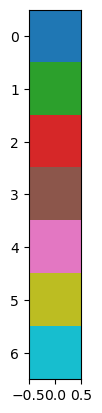

In [20]:
# generate colorbar with unique color for each mechanism
cdict, carr = plotutils.label_discrete_cmap(
    cmap=plt.get_cmap('tab10'),
    color_names=monomer_df.mechanism.unique(),
    hues_per_color=1
)
plt.imshow(carr)

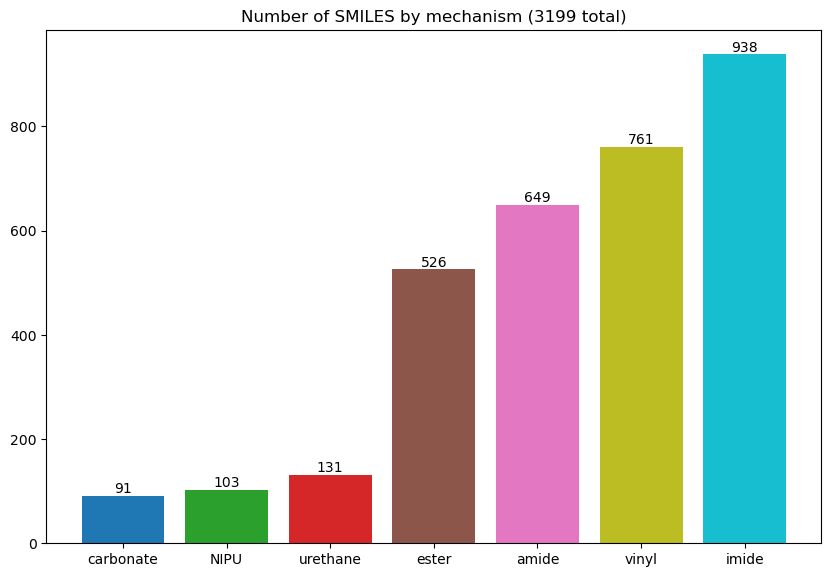

In [22]:
fig, ax = plotutils.presize_subplots(1, 1, scale=10, elongation=2/3)
bars = ax.bar(counts['mechanism'], counts['size'], color=cdict.values())
ax.set_title(f'Number of SMILES by {" & ".join(keys)} ({len(monomer_df)} total)')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), bar.get_height(), ha='center', va='bottom')

In [24]:
fig.savefig('monomer_data_raw/monomers_by_mechanism.png', bbox_inches='tight')

## Inspecting vinyl R-groups

In [ ]:
from typing import Generator, Iterable, Optional, Sequence

from polymerist.rdutils.labeling.molwise import (
    atom_ids_by_map_nums,
    assign_ordered_atom_map_nums,
    has_fully_mapped_atoms,
    clear_atom_map_nums,
    clear_atom_isotopes,
)


def extract_vinyl_R_groups(
        molecule : Chem.Mol, 
        mapped_query_mol : Chem.Mol, 
        r_group_bond_atom_nums : Iterable[tuple[int, int]], 
        dummy_labels : Optional[Sequence[int, int]]=None,
    ) -> Generator[Chem.Mol, None, None]:
    '''yields molecule fragments resulting from removal of each double-bonded carbon found in the molecule'''
    # sanitize dummy labels list
    if dummy_labels is None:
        dummy_labels = []
    else:
        assert len(dummy_labels) == len(r_group_bond_atom_nums)
    
    # query for vinyls
    mapped_molecule = assign_ordered_atom_map_nums(molecule)
    assert has_fully_mapped_atoms(mapped_molecule)
    assert has_fully_mapped_atoms(mapped_query_mol)
    
    query_matches = mapped_molecule.GetSubstructMatches(mapped_query_mol, useChirality=False)
    for match_indices in query_matches:
        modmol = Chem.RWMol(mapped_molecule) # create new editable copy of the molecule for each vinyl bond
        # generate correspondence between query map numbers and atom ids in queried molecule
        query_map_to_match_id : dict[int, int] = { # map from query map numbers to atom indices in the match
            atom.GetAtomMapNum() : match_id # relies on the fact that match atoms are returned in the same order as they appear in the query Mol
                for (atom, match_id) in zip(mapped_query_mol.GetAtoms(), match_indices)
        }
        
        # identify indices of objects to remove
        bond_ids_to_cut : list[int] = sorted((
                modmol.GetBondBetweenAtoms(
                    query_map_to_match_id[bond_start],
                    query_map_to_match_id[bond_end],
                ).GetIdx()
                    for (bond_start, bond_end) in r_group_bond_atom_nums
            ),
            reversed=True, # sort in descending order so each deletion doesn't affect those that follow it
        )
        
        # remove atom and bond targets and yield appropriate fragments
        frag_mol = Chem.FragmentOnBonds(modmol, bondIndices=bond_ids_to_cut, addDummies=True, dummyLabels=dummy_labels)
        for fragment in Chem.GetMolFrags(frag_mol, asMols=True):
            if fragment.GetSubstructMatch(mapped_query_mol): # don't return the central vinyl carbon fragments
                continue
            
            yield fragment

In [ ]:
# define vinyl group query and associated atom map numbers
# CC_DOUBLE_BOND_QUERY = Chem.MolFromSmarts('[C:1](-[*:3])(-[*:4])=[C:2](-[*:5])-[*:6]')
# CC_DOUBLE_BOND_ATOM_MAP_NUMS : tuple[int] = (1, 2) # map numbers on the vinyl carbons
# R_GROUP_MAP_NUMS : tuple[int] = (3, 4, 5, 6)  # map numbers of R-group bridgehead atoms

VINYL_QUERY = Chem.MolFromSmarts('[C:1](-[*:3])(-[H:4])=[C:2](-[H:5])-[H:6]')
VINYL_ATOM_MAP_NUMS : tuple[int] = (1, 2) # map numbers on the vinyl carbons
R_GROUP_MAP_NUMS : tuple[int] = (3,)  # map numbers of R-group bridgehead atoms

R_GROUP_BOND_MAP_NUMS : list[tuple[int, int]] = [  # select R-group-to-vinyl bonds for severance
    (vinyl_map_num, r_group_map_num)
        for vinyl_map_num in VINYL_ATOM_MAP_NUMS
            for r_group_map_num in R_GROUP_MAP_NUMS
                if VINYL_QUERY.GetBondBetweenAtoms(*atom_ids_by_map_nums(VINYL_QUERY, vinyl_map_num, r_group_map_num)) is not None
]

display(VINYL_QUERY)
print(R_GROUP_BOND_MAP_NUMS)

In [ ]:
from rdkit import RDLogger                                                                                                                                                               
from rich.progress import track


unique_R_groups : set[Chem.Mol]  = set()
unique_R_group_SMILES : set[str] = set()

subframe = grouper.get_group('vinyl')
num_mols = len(subframe)

not_actually_vinyls : list[tuple[int, str]] = []
RDLogger.DisableLog('rdApp.warning') # temporarily suppress unmapped hydrogen warnings
for i, row in track(subframe.iterrows(), description='Extracting unique vinyl R-groups...', total=num_mols):
    combo_mol = Chem.MolFromSmiles(row.smiles_explicit, sanitize=False)
    if not combo_mol.GetSubstructMatch(VINYL_QUERY):
        not_actually_vinyls.append( (i, row.smiles_explicit) )
        continue
        
    indiv_mols = Chem.GetMolFrags(combo_mol, asMols=True)
    num_indiv_mols = len(indiv_mols)
    
    for indiv_mol in indiv_mols:
        for frag in extract_vinyl_R_groups(
            indiv_mol, 
            mapped_query_mol=VINYL_QUERY, 
            r_group_bond_atom_nums=R_GROUP_BOND_MAP_NUMS, 
            dummy_labels=[(j, j) for (i, j) in R_GROUP_BOND_MAP_NUMS]
        ):
            unmapped_frag = clear_atom_map_nums(clear_atom_isotopes(frag))
            # display(unmapped_frag)
            
            canon_smi = Chem.CanonSmiles(Chem.MolToSmiles(unmapped_frag))
            if canon_smi not in unique_R_group_SMILES:
                unique_R_group_SMILES.add(canon_smi)
                unique_R_groups.add(unmapped_frag)
    
RDLogger.EnableLog('rdApp.warning') # re-enable warnings for other code

In [ ]:
len(not_actually_vinyls)

In [ ]:
subframe

In [ ]:
monomer_df

In [ ]:
not_actually_vinyls

In [ ]:
len(subframe)

In [ ]:
len(unique_R_group_SMILES)

In [ ]:
unique_R_group_SMILES

In [ ]:
from rdkit.Chem import Draw

img_dim = 400
n_mols_total = len(unique_R_groups)
row_width = int(np.sqrt(n_mols_total))

Draw.MolsToGridImage(list(unique_R_groups), molsPerRow=row_width, subImgSize=(img_dim, img_dim), maxMols=n_mols_total + 1)

In [ ]:
from polymerist.rdutils import rdkdraw
rdkdraw.set_rdkdraw_size(200, 3/2)

In [ ]:
Chem.GetMolFrags(indiv_mol, asMols=True)

# Visually inspecting monomer and oligomer units

In [ ]:
from polymerist.monomers import specification

# mech = 'ester'
mech = 'carbonate'
# mech = 'urethane'
# mech = 'vinyl'
# mech = 'imide'
num_mono = 2 # 1

frame = frames[(mech, num_mono)]

# ids = (23, 223)
ids = ()
n = 10
spacer = '=' * 25

test = defaultdict(list)
smaller = set()
for idx, row in frame.head(n).iterrows():
    if (not ids) or (idx in ids):
        # extract and visualize structures
        print(f'\n{spacer} {row["mechanism"]}-{idx} {spacer}\n')
        combined_smiles = row['smiles_monomer']
        combined_monomer = Chem.MolFromSmiles(combined_smiles, sanitize=False)
        display(combined_monomer)

        # dimer_smiles  = row['smiles_polymer_DP2']
        # dimer = Chem.MolFromSmiles(dimer_smiles)
        # display(dimer)

        # trimer_smiles = row['smiles_polymer_DP3']
        # trimer = Chem.MolFromSmiles(trimer_smiles)
        # display(trimer)

        for id in (1, 2):
            exp_mono_smi = row[f'smiles_expanded_monomer_{id}']
            monomer = Chem.MolFromSmiles(exp_mono_smi, sanitize=False)
            iupac_name = row[f'IUPAC_monomer_{id}']

            display(monomer)
            print(iupac_name)